# Airbnb Pricing Factor Analysis with PySpark

This notebook explores what drives Airbnb listing prices. It examines correlations between price and numeric factors, visualizes average price by borough and room type, and computes summary statistics across NYC neighbourhoods.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Start Spark Session

A Spark session is started for this analysis. If one is already running it will be reused.

In [2]:
spark = SparkSession.builder.appName("airbnb-pricing-factor-pyspark").getOrCreate()

26/05/02 01:27:47 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## Input Path

We point to the cleaned Airbnb dataset produced by the data cleaning pipeline. This should be the folder path if the output was written with `coalesce(1).write.csv(...)`.

In [3]:
INPUT_PATH = "airbnb_cleaned"

## Load Data

The cleaned CSV is read into a Spark DataFrame with all columns treated as strings initially. We print the shape and schema to confirm the file loaded correctly.

In [4]:
df = spark.read.csv(INPUT_PATH, header=True, inferSchema=False)

print("Shape:", (df.count(), len(df.columns)))
df.printSchema()

Shape: (101661, 28)
root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_identity_verified: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- long: string (nullable = true)
 |-- country: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- instant_bookable: string (nullable = true)
 |-- cancellation_policy: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- construction_year: string (nullable = true)
 |-- price: string (nullable = true)
 |-- service_fee: string (nullable = true)
 |-- minimum_nights: string (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: string (nullable = true)
 |-- review_rate_number: string (nullable = true)
 |-- calculated

## Helper Functions

`pick_existing` scans a list of candidate column names and returns the first one present in the DataFrame. `coerce_numeric` strips currency formatting characters and casts a column to double using a SQL expression.

In [5]:
def pick_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise ValueError(f"None of these columns found: {candidates}")

    return None


def coerce_numeric(df, col_name):
    if col_name is None or col_name not in df.columns:
        return df

    return df.withColumn(
        col_name,
        F.expr(
            f"""
            try_cast(
                regexp_replace(trim(cast(`{col_name}` as string)), '[$,]', '')
                as double
            )
            """
        )
    )

## Validate Price Column

We confirm that a `price` column exists before proceeding. If it is absent the notebook raises an error with a descriptive message rather than failing silently later.

In [6]:
if "price" not in df.columns:
    raise ValueError(
        "This dataset has no `price` column. Use a cleaned Airbnb dataset that includes price."
    )

## Missing Data Summary

We count null values per column and display the top 10 columns by missing count. This gives a quick check on data completeness after loading.

In [7]:
missing_exprs = [
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]

missing = df.select(*missing_exprs).toPandas().T
missing.columns = ["missing"]

missing.sort_values("missing", ascending=False).head(10)

26/05/02 01:27:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,missing
last_review,15982
review_year,15982
review_month,15982
country,525
construction_year,419
host_name,396
name,246
long,205
number_of_reviews,201
country_code,126


## Resolve Column Names

We detect which column names are available for rating, borough, and room type, since these can vary between cleaned dataset versions. The chosen column names are printed for transparency.

In [8]:
rating_col = pick_existing(
    df,
    ["review_rate_number", "review_scores_rating"],
    required=False
)

borough_col = pick_existing(
    df,
    ["neighbourhood_group", "neighbourhood_group_cleansed"],
    required=False
)

room_col = pick_existing(
    df,
    ["room_type"],
    required=False
)

print("Rating column:", rating_col)
print("Borough column:", borough_col)
print("Room column:", room_col)

Rating column: review_rate_number
Borough column: neighbourhood_group
Room column: room_type


## Numeric Cleaning

Price and the other numeric analysis columns are cast to doubles using `coerce_numeric`. Rows where price is null are dropped since price is the variable of interest throughout this notebook.

In [9]:
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    rating_col,
    "calculated_host_listings_count",
    "availability_365"
]

for c in numeric_cols:
    if c is not None and c in df.columns:
        df = coerce_numeric(df, c)

df = df.where(F.col("price").isNotNull())

print("Rows with non-null numeric price:", df.count())

Rows with non-null numeric price: 101661


## Correlation Analysis

We sample up to 100,000 rows, drop any rows with nulls in the selected columns, and compute a pairwise Pearson correlation matrix. This shows which factors move together with price.

In [10]:
corr_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    rating_col,
    "calculated_host_listings_count",
    "availability_365"
]

corr_cols = [
    c for c in corr_cols
    if c is not None and c in df.columns
]

corr_sample_pd = (
    df.select(*corr_cols)
    .dropna()
    .limit(100000)
    .toPandas()
)

print("Correlation sample rows:", len(corr_sample_pd))

corr_pd = corr_sample_pd.corr()
corr_pd

Correlation sample rows: 100000


,price,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
price,1.000000,-0.005473,-0.039562,0.030454,-0.002618,-0.010397,-0.001308
minimum_nights,-0.005473,1.000000,0.038633,0.044395,-0.001601,0.158583,0.113008
number_of_reviews,-0.039562,0.038633,1.000000,-0.000194,-0.031552,0.142187,-0.008945
reviews_per_month,0.030454,0.044395,-0.000194,1.000000,-0.003442,-0.001172,-0.007456
review_rate_number,-0.002618,-0.001601,-0.031552,-0.003442,1.000000,0.015736,0.006467
calculated_host_listings_count,-0.010397,0.158583,0.142187,-0.001172,0.015736,1.000000,0.169761
availability_365,-0.001308,0.113008,-0.008945,-0.007456,0.006467,0.169761,1.000000


## Correlation Heatmap

The correlation matrix is visualized as a colour-coded grid with numeric values annotated in each cell. Warmer colours indicate stronger positive correlation and cooler colours indicate negative or weak correlation.

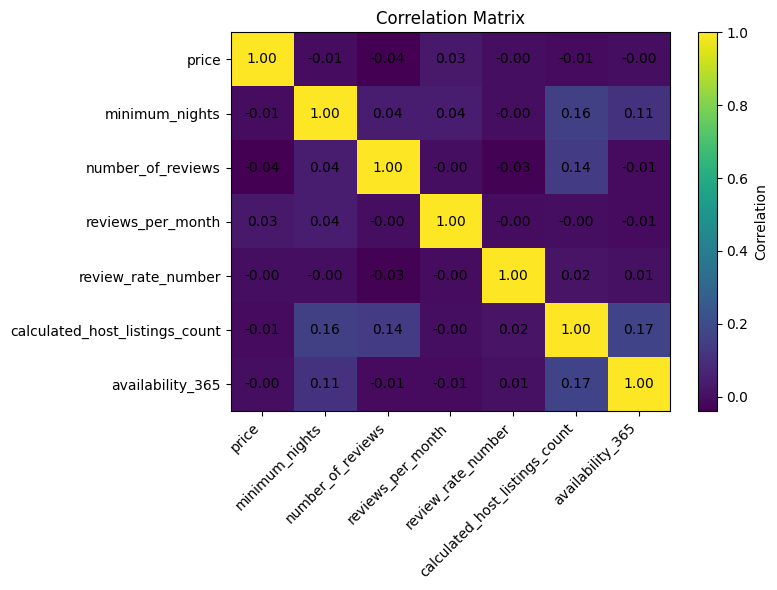

In [11]:
if not corr_pd.empty:
    plt.figure(figsize=(8, 6))
    plt.imshow(corr_pd.values, aspect="auto")
    plt.xticks(range(len(corr_pd.columns)), corr_pd.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_pd.index)), corr_pd.index)
    plt.colorbar(label="Correlation")

    for i in range(len(corr_pd.index)):
        for j in range(len(corr_pd.columns)):
            plt.text(j, i, f"{corr_pd.iloc[i, j]:.2f}", ha="center", va="center")

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping correlation heatmap: no valid numeric data.")

## Prepare Scatter Plot Sample

A random 20% sample capped at 50,000 rows is drawn for scatter plots. Sampling keeps the visualizations fast to render without overplotting.

In [12]:
scatter_cols = [
    c for c in [rating_col, "price", "reviews_per_month"]
    if c is not None and c in df.columns
]

sample_pd = (
    df.select(*scatter_cols)
    .dropna()
    .sample(withReplacement=False, fraction=0.2, seed=42)
    .limit(50000)
    .toPandas()
)

if sample_pd.empty:
    sample_pd = (
        df.select(*scatter_cols)
        .dropna()
        .limit(50000)
        .toPandas()
    )

print("Scatter sample rows:", len(sample_pd))

Scatter sample rows: 20476


## Review Rating vs Price

A scatter plot of review rating against price helps visualize whether higher-rated listings tend to command higher prices.

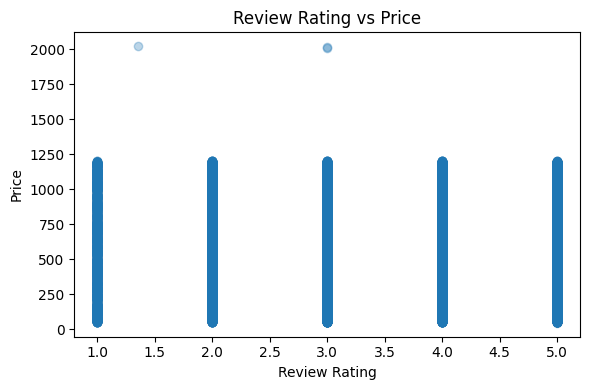

In [13]:
if rating_col is not None and rating_col in sample_pd.columns and not sample_pd.empty:
    plt.figure(figsize=(6, 4))
    plt.scatter(sample_pd[rating_col], sample_pd["price"], alpha=0.3)
    plt.xlabel("Review Rating")
    plt.ylabel("Price")
    plt.title("Review Rating vs Price")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping rating plot: rating column not available.")

## Reviews per Month vs Price

This scatter plot examines whether more frequently reviewed listings (a proxy for booking activity) are associated with higher or lower prices.

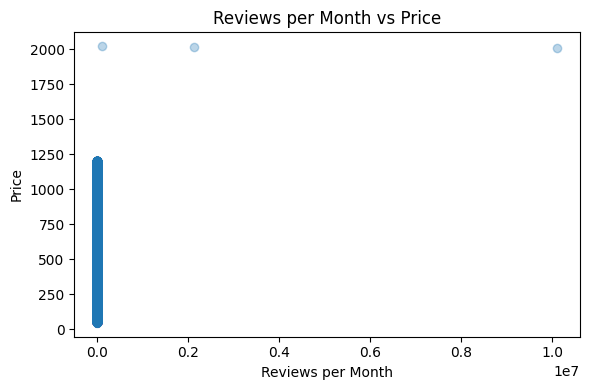

In [14]:
if "reviews_per_month" in sample_pd.columns and not sample_pd.empty:
    plt.figure(figsize=(6, 4))
    plt.scatter(sample_pd["reviews_per_month"], sample_pd["price"], alpha=0.3)
    plt.xlabel("Reviews per Month")
    plt.ylabel("Price")
    plt.title("Reviews per Month vs Price")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping reviews-per-month plot: column not available.")

## Price Summary Statistics

Spark's `describe` function returns count, mean, standard deviation, min, and max for the price column. This gives a baseline sense of the price distribution.

In [15]:
df.select("price").describe().show()

+-------+-----------------+
|summary|            price|
+-------+-----------------+
|  count|           101661|
|   mean|624.5065561031271|
| stddev|332.3914702029913|
|    min|             10.0|
|    max|           2022.0|
+-------+-----------------+



## Average Price by Borough

We filter to the five recognized NYC boroughs, compute the average price per borough, and plot the results as a bar chart. Only valid borough names are included to avoid noise from typos or nulls.

+-------------------+-----------------+
|neighbourhood_group|avg_price        |
+-------------------+-----------------+
|Queens             |629.8569789674953|
|Bronx              |628.2402255639098|
|Brooklyn           |626.4951367267637|
|Staten Island      |624.031914893617 |
|Manhattan          |622.6465946843854|
+-------------------+-----------------+



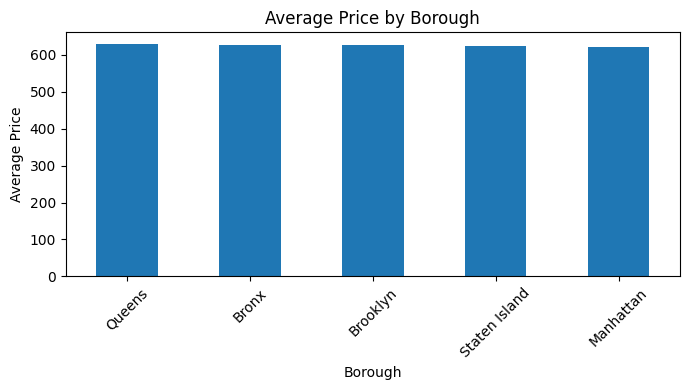

In [16]:
valid_boroughs = [
    "Bronx",
    "Brooklyn",
    "Manhattan",
    "Queens",
    "Staten Island"
]

if borough_col is not None:
    borough_df = df.filter(F.col(borough_col).isin(valid_boroughs))

    avg_price_borough = (
        borough_df.groupBy(borough_col)
        .agg(F.avg("price").alias("avg_price"))
        .orderBy(F.desc("avg_price"))
    )

    avg_price_borough.show(truncate=False)

    avg_price_borough_pd = avg_price_borough.toPandas().set_index(borough_col)

    if not avg_price_borough_pd.empty:
        avg_price_borough_pd["avg_price"].plot(kind="bar", figsize=(7, 4))
        plt.title("Average Price by Borough")
        plt.ylabel("Average Price")
        plt.xlabel("Borough")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping borough plot: no valid borough data available.")
else:
    print("Skipping borough plot: borough column not found.")

## Average Price by Room Type

The same analysis is repeated for room type. Average prices are compared across entire homes, private rooms, shared rooms, and hotel rooms.

+---------------+-----------------+
|room_type      |avg_price        |
+---------------+-----------------+
|Hotel room     |666.3913043478261|
|Shared room    |635.2199453551913|
|Entire home/apt|625.3407465944156|
|Private room   |624.6921922901311|
+---------------+-----------------+



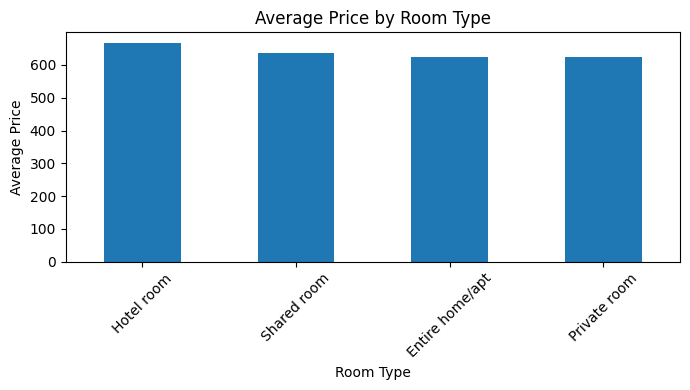

In [17]:
valid_room_types = [
    "Entire home/apt",
    "Private room",
    "Shared room",
    "Hotel room"
]

if room_col is not None:
    room_df = df.filter(F.col(room_col).isin(valid_room_types))

    avg_price_room = (
        room_df.groupBy(room_col)
        .agg(F.avg("price").alias("avg_price"))
        .orderBy(F.desc("avg_price"))
    )

    avg_price_room.show(truncate=False)

    avg_price_room_pd = avg_price_room.toPandas().set_index(room_col)

    if not avg_price_room_pd.empty:
        avg_price_room_pd["avg_price"].plot(kind="bar", figsize=(7, 4))
        plt.title("Average Price by Room Type")
        plt.ylabel("Average Price")
        plt.xlabel("Room Type")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping room type plot: no valid room type data available.")
else:
    print("Skipping room type plot: room_type column not found.")

## Borough Price Statistics

For each borough we compute min, max, mean, median, standard deviation, and price range. The range column highlights how much price spread exists within each area.

In [18]:
valid_boroughs = [
    "Bronx",
    "Brooklyn",
    "Manhattan",
    "Queens",
    "Staten Island"
]

if borough_col is not None:
    borough_df = df.filter(F.col(borough_col).isin(valid_boroughs))

    borough_stats = (
        borough_df.groupBy(borough_col)
        .agg(
            F.min("price").alias("min"),
            F.max("price").alias("max"),
            F.avg("price").alias("mean"),
            F.expr("percentile_approx(price, 0.5)").alias("median"),
            F.stddev("price").alias("std")
        )
        .withColumn("range", F.col("max") - F.col("min"))
        .orderBy(F.desc("mean"))
    )

    borough_stats.show(truncate=False)
else:
    print("Skipping borough statistics: borough column not found.")

+-------------------+----+------+-----------------+------+-----------------+------+
|neighbourhood_group|min |max   |mean             |median|std              |range |
+-------------------+----+------+-----------------+------+-----------------+------+
|Queens             |50.0|1200.0|629.8569789674953|627.0 |334.0735229721256|1150.0|
|Bronx              |50.0|1200.0|628.2402255639098|633.0 |324.2552977486082|1150.0|
|Brooklyn           |50.0|1200.0|626.4951367267637|626.0 |331.9147188025609|1150.0|
|Staten Island      |50.0|1200.0|624.031914893617 |628.0 |326.4968887488463|1150.0|
|Manhattan          |50.0|1200.0|622.6465946843854|621.0 |331.2283387803209|1150.0|
+-------------------+----+------+-----------------+------+-----------------+------+



## End of Analysis

All pricing factor visualizations and summaries are complete. You can stop the Spark session here if no further work is needed.